# A. Dataset Selection

I have selected the Amazon Sales Dataset for my project.

Link: https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset/data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\zacha\.cache\kagglehub\datasets\karkavelrajaj\amazon-sales-dataset\versions\1


Reasons:
- Supports both bucket-item analysis as well as text mining.
- Many possibilities for analysis.

Trade-offs:
- Need to handle Null values.
- Text blocks may be difficult to handle.

This dataset is a list of products and reviews. It includes a description of the product and product information such as price. It also includes a review for each product and an average rating from all customers. The code below displays the column information as well as a sample of the dataset.

In [2]:
import os
import glob
import pandas as pd

# KaggleHub gives a *directory* path; find the CSV inside it
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in directory: {path}")

csv_path = csv_files[0]
print("Using CSV file:", csv_path)

# Load dataset
df = pd.read_csv(csv_path)

# Clean and convert numeric columns
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

def _clean_price(series):
    return (series.astype(str)
                  .str.replace('₹', '', regex=False)
                  .str.replace(',', '', regex=False)
                  .str.strip())

df['discounted_price'] = pd.to_numeric(_clean_price(df['discounted_price']), errors='coerce').astype('Float64')
df['actual_price'] = pd.to_numeric(_clean_price(df['actual_price']), errors='coerce').astype('Float64')

df['discount_percentage'] = pd.to_numeric(
    df['discount_percentage'].astype(str).str.replace('%', '', regex=False).str.strip(),
    errors='coerce',
).astype('Int64')

df['rating_count'] = pd.to_numeric(
    df['rating_count'].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce',
).astype('Int64')

# Basic info
df.info()
display(df.head())  # first five rows

Using CSV file: C:\Users\zacha\.cache\kagglehub\datasets\karkavelrajaj\amazon-sales-dataset\versions\1\amazon.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   Float64
 4   actual_price         1465 non-null   Float64
 5   discount_percentage  1465 non-null   Int64  
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   Int64  
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       146

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Research Questions

I chose to ask two questions that are tightly connected because I wanted to explore both reviews and ratings which are two different methods of evaluating a product. 
- "Are ratings biased by the category or discounted amount?"
- "What clusters emerge from review text embeddings?"



## Resources.

On my honor, I declare the following resources:
1. Collaborators:
None

2. Web Sources:
- https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset/data
- https://github.com/zacharydaniel229/CSCE676_ZacharyWilliams_Project : I reused code from my previous assignment

3. AI Tools:
None

# B. Research Question 1

## Introduction

Are ratings biased by the category or discounted amount?
- Data mining task type: Large-scale ml

- Motivation: We want to determine if the rating is a good measure of the quality of the product.
- Non-triviality: We use several features to determine correlation and several different methods to evaluate feature correlation.
- Feasibility: The features are all available in the dataset and the algorithms are easy to implement.
- Risks: There are null values within some feature columns.

- Course algorithms: randomForests 
- External algorithms: kruskal-wallis 
- Evaluation: MSE, R^2 score
- Baseline: Ratings predicted with actual price. 

## EDA

First we will decide whether or not the discount affects the rating. We will first train a random forest that predicts the rating using discounted price and the number of ratings as features. We will use MSE and R2 to evaluate the model.

In [4]:
# Predict rating using discounted_price and rating_count
# Random Forest is used for numeric rating prediction.

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Keep only rows with the features and target we need
model_df = df[['discounted_price', 'rating_count', 'rating']].dropna().copy()
X = model_df[['discounted_price', 'rating_count']]
y = model_df['rating']

# Split and train the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print('Random Forest Regression')
print('MSE:', mean_squared_error(y_test, rf_predictions))
print('R^2:', r2_score(y_test, rf_predictions))

scores = cross_val_score(rf_model, X, y, cv=10, scoring='neg_mean_squared_error')
mse_scoresA = -scores
r2_scoresA = cross_val_score(rf_model, X, y, cv=10, scoring='r2')

Random Forest Regression
MSE: 0.07715195648464178
R^2: 0.05682900501957855


The MSE and R2 values show that these features are not very good for predicting the result. However, we want to know if the discount helps. So we will create an identical model but with actual price instead of discounted price.

In [5]:
# Predict rating using actual_price and rating_count
# Random Forest is used for numeric rating prediction.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Keep only rows with the features and target we need
model_df = df[['actual_price', 'rating_count', 'rating']].dropna().copy()
X = model_df[['actual_price', 'rating_count']]
y = model_df['rating']

# Split and train the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print('Random Forest Regression')
print('MSE:', mean_squared_error(y_test, rf_predictions))
print('R^2:', r2_score(y_test, rf_predictions))

scores = cross_val_score(rf_model, X, y, cv=10, scoring='neg_mean_squared_error')
mse_scoresB = -scores
r2_scoresB = cross_val_score(rf_model, X, y, cv=10, scoring='r2')

Random Forest Regression
MSE: 0.07947389846416353
R^2: 0.028443615628341412


The MSE and R2 values look pretty similar. However, we want a measurable result to show if discount affects the result or not. We will use cross val score to create confidence intervals so we can know for sure.

In [6]:
import numpy as np

diff = mse_scoresA - mse_scoresB

mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)

ci_diff = 1.96 * (std_diff / np.sqrt(len(diff)))

print(f"MSE difference: {mean_diff:.4f} ± {ci_diff:.4f}")

r2_diff = r2_scoresA - r2_scoresB

mean_r2_diff = np.mean(r2_diff)
std_r2_diff = np.std(r2_diff, ddof=1)

ci_r2_diff = 1.96 * (std_r2_diff / np.sqrt(len(r2_diff)))

print(f"R^2 difference: {mean_r2_diff:.4f} ± {ci_r2_diff:.4f}")

MSE difference: -0.0006 ± 0.0031
R^2 difference: -0.0049 ± 0.0443


0 is included in both intervals so we do not have evidence that discount affects the rating of the product.

Now we will determine if the category affects the product rating. We will start by taking a look at all the categories and their counts.

In [7]:
# Build a dictionary: category -> number of products in that category
category_counts = {}

for categories in df['category'].dropna():
    # Split multi-category entries (e.g., "A|B|C")
    for cat in str(categories).split('|'):
        cat = cat.strip()
        if cat:
            category_counts[cat] = category_counts.get(cat, 0) + 1

# Print the number of unique categories
print("Number of categories:", len(category_counts))

countBiggerThan30 = sum(1 for count in category_counts.values() if count > 30)
print("Number of categories with more than 30 products:", countBiggerThan30)
# Print each category and its product count
for cat, count in sorted(category_counts.items()):
    if count > 30:
        print(f"{cat}: {count}")

Number of categories: 317
Number of categories with more than 30 products: 35
Accessories: 111
Accessories&Peripherals: 381
Cables: 267
Cables&Accessories: 240
Chargers: 33
Computers&Accessories: 453
Electronics: 526
Headphones: 62
Headphones,Earbuds&Accessories: 66
Heating,Cooling&AirQuality: 116
Home&Kitchen: 448
HomeTheater,TV&Video: 162
In-Ear: 52
Irons: 36
Irons,Steamers&Accessories: 58
Kettles&HotWaterDispensers: 32
Keyboards,Mice&InputDevices: 60
Kitchen&HomeAppliances: 308
LaptopAccessories: 34
MobileAccessories: 84
Mobiles&Accessories: 161
NetworkingDevices: 34
OfficeProducts: 31
RemoteControls: 49
RoomHeaters: 46
SmallKitchenAppliances: 181
SmartTelevisions: 63
SmartWatches: 76
Smartphones: 68
Smartphones&BasicMobiles: 77
Televisions: 69
USBCables: 233
Vacuum,Cleaning&Ironing: 82
WaterHeaters&Geysers: 44
WearableTechnology: 76


There are 317 categories, but there are only 35 categories that have at least 30 products.

Because a lot of the categories overlap, I chose to do my analysis with Computers&Accessories, Electronics, and Home&Kitchen. Even if I put the rest of the products in category "other," that category would be about 5x smaller than the rest.

I chose to use the Kruskal-Wallis test to test whether the rating distribution differs substantially across the categories. I chose this because the distribution may not be normal.

In [8]:
# Test 2: Kruskal-Wallis test for rating differences across categories
from scipy.stats import kruskal

# Use the top 3 categories by product count.
top_3_categories = {
    cat for cat, _ in sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:3]
}

# Assign each product to one primary category from top 3 only.
# If a product belongs to multiple top-3 categories, choose the larger category.
# If none of its categories are in the top 3, exclude it.
def _primary_category_top3(category_value):
    candidates = []
    for cat in str(category_value).split('|'):
        cat = cat.strip()
        if cat and cat in top_3_categories:
            candidates.append(cat)
    if not candidates:
        return None
    return max(candidates, key=lambda cat: (category_counts.get(cat, 0), cat))

kruskal_df = df[['category', 'rating']].dropna().copy()
kruskal_df['primary_category'] = kruskal_df['category'].apply(_primary_category_top3)
kruskal_df = kruskal_df.dropna(subset=['primary_category'])

category_groups = [
    group['rating'].values
    for _, group in kruskal_df.groupby('primary_category')
    if len(group) > 1
]

print('Kruskal-Wallis test on rating by primary category (top 3 only)')
print('Top-3 categories selected:', len(top_3_categories))
print('Rows used in test:', len(kruskal_df))
print('Number of groups in test:', len(category_groups))
print('Category counts:')
print(kruskal_df['primary_category'].value_counts().sort_index())

kw_stat, kw_p = kruskal(*category_groups)
print('H statistic:', kw_stat)
print('p-value:', kw_p)
if kw_p < 0.05:
    print('Result: ratings differ significantly across categories.')
else:
    print('Result: no statistically significant category difference detected.')

Kruskal-Wallis test on rating by primary category (top 3 only)
Top-3 categories selected: 3
Rows used in test: 1426
Number of groups in test: 3
Category counts:
primary_category
Computers&Accessories    453
Electronics              526
Home&Kitchen             447
Name: count, dtype: int64
H statistic: 38.26368737556011
p-value: 4.910727752065028e-09
Result: ratings differ significantly across categories.


Using the Kruskal-Wallis test, we can determine that the rating distribution differs significantly across the categories.

One problem with this test is that we can only determine that their is a difference within all of the categories. We want to pairwise check. For this reason, I am also using regression with category features.

In [9]:
# Test 3: Regression with category indicators and a partial F-test
import numpy as np
from scipy.stats import f as f_dist

# Use the top 3 categories by product count.
top_3_categories = {
    cat for cat, _ in sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:3]
}

# Assign each product to one primary category from top 3 only.
# If a product belongs to multiple top-3 categories, choose the larger category.
# If none of its categories are in the top 3, exclude it.
def _primary_category_top3(category_value):
    candidates = []
    for cat in str(category_value).split('|'):
        cat = cat.strip()
        if cat and cat in top_3_categories:
            candidates.append(cat)
    if not candidates:
        return None
    return max(candidates, key=lambda cat: (category_counts.get(cat, 0), cat))

regression_df = df[['category', 'discounted_price', 'rating_count', 'rating']].dropna().copy()
regression_df['primary_category'] = regression_df['category'].apply(_primary_category_top3)
regression_df = regression_df.dropna(subset=['primary_category'])

# One-hot encode the primary category. The dropped category is the reference category.
category_dummies = pd.get_dummies(regression_df['primary_category'], prefix='cat', drop_first=True)
control_variables = regression_df[['discounted_price', 'rating_count']].astype(float)
y = regression_df['rating'].astype(float).to_numpy()

X_full = np.column_stack([
    np.ones(len(regression_df)),
    control_variables.to_numpy(),
    category_dummies.to_numpy(),
])
X_reduced = np.column_stack([
    np.ones(len(regression_df)),
    control_variables.to_numpy(),
])

beta_full, *_ = np.linalg.lstsq(X_full, y, rcond=None)
beta_reduced, *_ = np.linalg.lstsq(X_reduced, y, rcond=None)

resid_full = y - X_full @ beta_full
resid_reduced = y - X_reduced @ beta_reduced
sse_full = float(np.sum(resid_full ** 2))
sse_reduced = float(np.sum(resid_reduced ** 2))

n = len(y)
p_full = X_full.shape[1]
p_reduced = X_reduced.shape[1]
q = p_full - p_reduced

df_full = n - p_full
f_stat = ((sse_reduced - sse_full) / q) / (sse_full / df_full)
p_value = f_dist.sf(f_stat, q, df_full)

print('Regression with category indicators (top 3 only)')
print('Top-3 categories selected:', len(top_3_categories))
print('Rows used in regression:', len(regression_df))
print('Categories in regression design:', regression_df['primary_category'].nunique())
print('Full model R^2:', 1 - (sse_full / np.sum((y - y.mean()) ** 2)))
print('Partial F-test for adding category indicators')
print('F statistic:', f_stat)
print('p-value:', p_value)

category_coefs = pd.Series(beta_full[3:], index=category_dummies.columns).sort_values()
print('\nCategory coefficients relative to the reference category:')
print(category_coefs)

if p_value < 0.05:
    print('\nResult: category indicators add explanatory power after controlling for price and rating count.')
else:
    print('\nResult: category indicators do not add statistically significant explanatory power after controls.')

Regression with category indicators (top 3 only)
Top-3 categories selected: 3
Rows used in regression: 1424
Categories in regression design: 3
Full model R^2: 0.0642035871837423
Partial F-test for adding category indicators
F statistic: 26.42742644051892
p-value: 5.386458839726464e-12

Category coefficients relative to the reference category:
cat_Electronics    -0.121905
cat_Home&Kitchen   -0.117464
dtype: float64

Result: category indicators add explanatory power after controlling for price and rating count.


We can determine that Computers&Accessories is significantly differ to both electronics and home&kitchen.

We also want to pairwise compare electronics and home&kitchen. We will redo the test with electronics as the reference point.

In [10]:
# Follow-up: p-value for Home&Kitchen coefficient (Electronics reference)
import numpy as np
from scipy.stats import t as t_dist

# Rebuild the same Electronics-reference regression design used above.
top_3_categories = {
    cat for cat, _ in sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:3]
}

def _primary_category_top3(category_value):
    candidates = []
    for cat in str(category_value).split('|'):
        cat = cat.strip()
        if cat and cat in top_3_categories:
            candidates.append(cat)
    if not candidates:
        return None
    return max(candidates, key=lambda cat: (category_counts.get(cat, 0), cat))

regression_df = df[['category', 'discounted_price', 'rating_count', 'rating']].dropna().copy()
regression_df['primary_category'] = regression_df['category'].apply(_primary_category_top3)
regression_df = regression_df.dropna(subset=['primary_category'])

category_dummies = pd.get_dummies(regression_df['primary_category'], prefix='cat', drop_first=False)
category_dummies = category_dummies.drop(columns=['cat_Electronics'])

control_variables = regression_df[['discounted_price', 'rating_count']].astype(float)
y = regression_df['rating'].astype(float).to_numpy()

X_full = np.column_stack([
    np.ones(len(regression_df)),
    control_variables.to_numpy(),
    category_dummies.to_numpy(),
])

beta_full, *_ = np.linalg.lstsq(X_full, y, rcond=None)
resid_full = y - X_full @ beta_full
n = len(y)
p_full = X_full.shape[1]
df_resid = n - p_full
sigma2 = np.sum(resid_full ** 2) / df_resid

# Variance-covariance matrix and coefficient-specific test
xtx_inv = np.linalg.inv(X_full.T @ X_full)
se = np.sqrt(np.diag(sigma2 * xtx_inv))

coef_names = ['Intercept', 'discounted_price', 'rating_count'] + list(category_dummies.columns)
target_name = 'cat_Home&Kitchen'
idx = coef_names.index(target_name)

coef_val = beta_full[idx]
se_val = se[idx]
t_stat = coef_val / se_val
p_val = 2 * t_dist.sf(abs(t_stat), df=df_resid)

print('Coefficient:', coef_val)
print('Standard error:', se_val)
print('t-statistic:', t_stat)
print('p-value for Home&Kitchen coefficient:', p_val)

if p_val < 0.05:
    print('\nResult: category indicators add explanatory power after controlling for price and rating count.')
else:
    print('\nResult: category indicators do not add statistically significant explanatory power after controls.')

Coefficient: 0.0044414981425771475
Standard error: 0.019080478684048906
t-statistic: 0.23277708154618765
p-value for Home&Kitchen coefficient: 0.8159680801883812

Result: category indicators do not add statistically significant explanatory power after controls.


We do not have evidence that electronics and home&kitchen have significantly different ratings.

## Results

We set out to determine if the ratings are biased by either the discounted price or the category.

To determine if the discounted_price affected the rating, I trained two randomForest models using rating count and either price or discounted price as features. I added rating count as a feature so that the model will not be as reliant on the price if the data does not naturally rely on price. I calculated MSE and R2 for each model and created confidence intervals for the difference of each statistic from the two models. Both confidence intervals included zero so we do not have evidence that the discounted price affects the rating of the product.

To determine if the category affects the rating, we take the largest three categories, Computers&Accessories, Electronics, and Home&Kitchen, and run the Kruskal-Wallis test on the three categories to determine if there is a significant difference between the ratings of the categories. The test produced a p value of about 5e-09 so are able to conclude that there is a significant difference between the ratings of at least one category.

Expanding on this discovery, I used regression with categories as features and found coefficients for specific categories. Then we check if there is a significant difference between each category. I used Computers&Accessories as the reference category and got coefficients for electronics and home&kitchen relative to the reference category. These coefficients allowed me to get a p-value that allowed us to reject the potential for category not having an effect on the ratings. I noticed that the coefficient for electronics and home&kitchen were similar. I ran the test again but with electronics as the reference and only using home&kitchen for the p-value. We were unable to find evidence that category changes the rating when looking only at electronics and home&kitchen.

It makes sense that the discount does not affect the rating because the product is not always discounted and the majority of ratings likely do not come from the discounted period.

I am not surprised that the category affects the rating because it is harder to determine the quality of a product online for some products. I am surprised that Computers&accessories has significantly different ratings than the other two big categories, but electronics and home&kitchen do not have significantly different ratings from each other. I would think that electronics would be more similar to computers&accessories. I do not have an explanation for this.

## Resources.

On my honor, I declare the following resources:
1. Collaborators:
None

2. Web Sources:
None

3. AI Tools:
Github Copilot Agent (GPT-5.1): I prompted for code one cell at a time and wrote analysis in between. I had to rewrite cells a few time.

# C. Research Question 2

## Introduction

What clusters emerge from review text embeddings?
- Data mining task type: Text mining, clustering
- Motivation: We want to see if there are any interesting clusters that are formed from the review text embeddings and how they compare to other ways that we may cluster the data.
- Non-triviality: We will cluster the data using several different methods and use several different features.
- Feasibility: Clustering algorithms and evaluation are very implementable.
- Risks: The clusters may not resemble any useful information.
- Course algorithms: word2vec, k-means
- External algorithms: BERT
- Evaluation criteria: silhouette score, purity score
- Baseline: categories as ground truth

## EDA

We want to see if there are any interesting clusters that emerge from the review text embeddings. The first step of this is to generate the text embeddings. First we will use word2vec.

In [9]:
# Option 1: Train Word2Vec on review_content and create review-level embeddings
import re
import numpy as np
from gensim.models import Word2Vec

# Prepare text
text_series = df['review_content'].fillna('').astype(str)

def tokenize(text):
    # Keep alphabetic tokens and lowercase everything
    return re.findall(r'[a-zA-Z]+', text.lower())

tokenized_reviews = text_series.apply(tokenize).tolist()

# Train Word2Vec on this corpus
embedding_dim = 100
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=embedding_dim,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    seed=42,
)

# Build one embedding per review by averaging token vectors
def average_embedding(tokens, model, dim):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vectors, axis=0)

review_embeddings = np.vstack([
    average_embedding(tokens, w2v_model, embedding_dim)
    for tokens in tokenized_reviews
])

# Optional: store as a list column on df for downstream modeling
df['review_embedding'] = review_embeddings.tolist()

print('Word2Vec training complete.')
print('Vocabulary size:', len(w2v_model.wv))
print('Embedding dimension:', embedding_dim)
print('Review embedding matrix shape:', review_embeddings.shape)
print('First 5 values of first review embedding:', review_embeddings[0][:5])

Word2Vec training complete.
Vocabulary size: 7344
Embedding dimension: 100
Review embedding matrix shape: (1465, 100)
First 5 values of first review embedding: [-0.06868413  0.30214092 -0.2169282  -0.15346593 -0.087111  ]


To get a larger view of the data, we will also use BERT to generate embeddings. BERT creates embeddings based on context so it is different than word2vec. 

In [3]:
# Option 2: Generate BERT-based review embeddings
# This creates one contextual embedding per review using DistilBERT.

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

bert_model_name = 'distilbert-base-uncased'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Loading BERT model: {bert_model_name}')
print(f'Using device: {device}')

tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to(device)
bert_model.eval()

# Reuse review text and build contextual embeddings in batches
bert_texts = df['review_content'].fillna('').astype(str).tolist()
batch_size = 32
max_length = 128
bert_embedding_list = []

with torch.no_grad():
    for i in range(0, len(bert_texts), batch_size):
        batch = bert_texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        outputs = bert_model(**encoded)
        token_embeddings = outputs.last_hidden_state
        attention_mask = encoded['attention_mask'].unsqueeze(-1)

        # Mean pooling over valid tokens only
        masked_embeddings = token_embeddings * attention_mask
        summed = masked_embeddings.sum(dim=1)
        counts = attention_mask.sum(dim=1).clamp(min=1)
        batch_embeddings = summed / counts

        bert_embedding_list.append(batch_embeddings.cpu().numpy())

bert_review_embeddings = np.vstack(bert_embedding_list).astype(np.float32)
df['bert_review_embedding'] = bert_review_embeddings.tolist()

print('BERT embedding generation complete.')
print('BERT embedding matrix shape:', bert_review_embeddings.shape)
print('First 5 values of first BERT review embedding:', bert_review_embeddings[0][:5])

Loading BERT model: distilbert-base-uncased
Using device: cpu


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\zacha\Downloads\CSCE676\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zacha\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT embedding generation complete.
BERT embedding matrix shape: (1465, 768)
First 5 values of first BERT review embedding: [-0.00871011 -0.17167157  0.5067794   0.15309754  0.41718358]


In order to cluster the embeddings, we must use PCA to project the embeddings into 2D so that we can view them graphically. We will start with word2vec.

PCA explained variance ratio: [0.20486015 0.0853051 ]
Total explained variance (2 components): 0.29016525


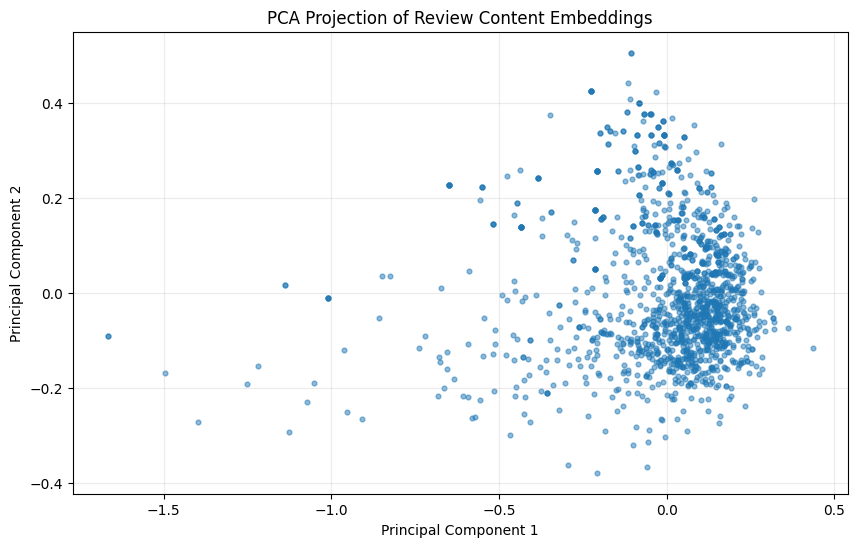

In [13]:
# PCA projection of Word2Vec review embeddings (2D) and scatter plot
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# If embeddings are in list form, convert to a numeric matrix
if not isinstance(review_embeddings, np.ndarray):
    embedding_matrix = np.array(review_embeddings)
else:
    embedding_matrix = review_embeddings

pca = PCA(n_components=2, random_state=42)
embedding_2d = pca.fit_transform(embedding_matrix)

print('PCA explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance (2 components):', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=12, alpha=0.5)
plt.title('PCA Projection of Review Content Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.25)
plt.show()

Now we will use k-means to cluster the embeddings to see if any interesting clusters emerge. We will use silhouette score to evaluate the clusters as well as purity using category as ground truth to see if certain words used in a review correspond to a specific category. We set k = 3 because there are three categories.

K-means clustering with k=3 (excluding Other)
Rows used (non-Other only): 1427
Silhouette score: 0.1197


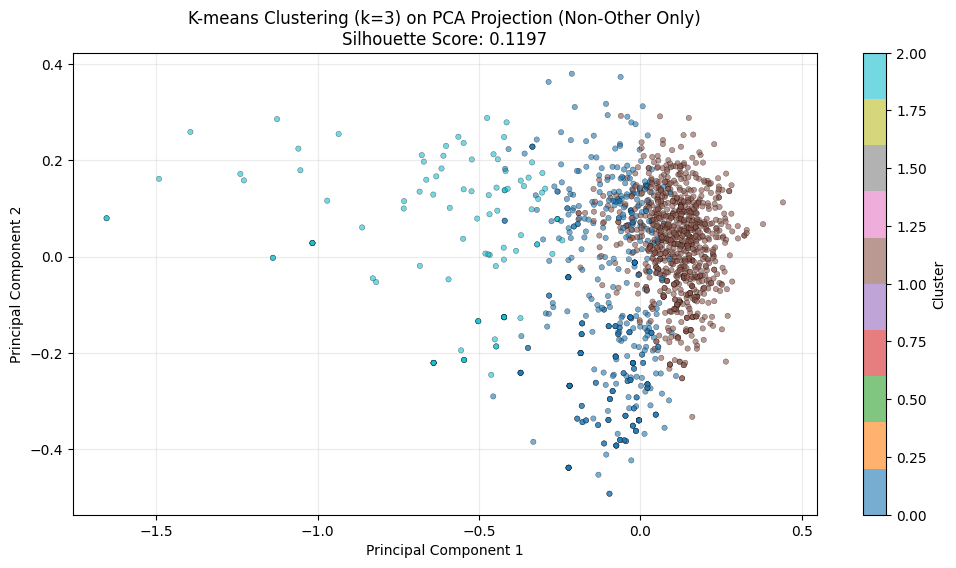


Cluster distribution:
Cluster 0: 438 reviews
Cluster 1: 887 reviews
Cluster 2: 102 reviews

--- Purity Evaluation ---
Ground truth categories used: ['Computers&Accessories', 'Electronics', 'Home&Kitchen']
Purity score: 0.4646

--- Cluster vs Ground Truth Distribution ---

Cluster 0 (total reviews: 438):
  Computers&Accessories: 227 (51.8%)
  Electronics: 112 (25.6%)
  Home&Kitchen: 99 (22.6%)

Cluster 1 (total reviews: 887):
  Computers&Accessories: 181 (20.4%)
  Electronics: 391 (44.1%)
  Home&Kitchen: 315 (35.5%)

Cluster 2 (total reviews: 102):
  Computers&Accessories: 45 (44.1%)
  Electronics: 23 (22.5%)
  Home&Kitchen: 34 (33.3%)


In [10]:
# K-means clustering with k=3 and silhouette score evaluation (excluding category Other)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Configure display to avoid truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

# Ensure embeddings and 2D projection exist (self-contained cell)
if 'embedding_matrix' not in globals():
    if not isinstance(review_embeddings, np.ndarray):
        embedding_matrix = np.array(review_embeddings)
    else:
        embedding_matrix = review_embeddings

if 'embedding_2d' not in globals():
    pca = PCA(n_components=2, random_state=42)
    embedding_2d = pca.fit_transform(embedding_matrix)

# Build ground truth categories first
# Define the top 3 categories
top_3_categories = {
    cat for cat, _ in sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:3]
}

# Assign ground truth labels: map each review to one of 4 categories (top 3 + Other)
def _assign_ground_truth_category(category_value):
    candidates = []
    for cat in str(category_value).split('|'):
        cat = cat.strip()
        if cat and cat in top_3_categories:
            candidates.append(cat)
    if not candidates:
        return 'Other'
    return max(candidates, key=lambda cat: (category_counts.get(cat, 0), cat))

ground_truth_categories = df['category'].apply(_assign_ground_truth_category).values

# Exclude rows that are in category Other for clustering/plotting/evaluation
non_other_mask = ground_truth_categories != 'Other'
embedding_matrix_no_other = embedding_matrix[non_other_mask]
embedding_2d_no_other = embedding_2d[non_other_mask]
ground_truth_no_other = ground_truth_categories[non_other_mask]

# Use k=3
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
best_labels = kmeans.fit_predict(embedding_matrix_no_other)
best_silhouette = silhouette_score(embedding_matrix_no_other, best_labels)

print(f'K-means clustering with k={k} (excluding Other)')
print(f'Rows used (non-Other only): {embedding_matrix_no_other.shape[0]}')
print(f'Silhouette score: {best_silhouette:.4f}')

# Visualize clusters on PCA projection (non-Other points only)
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    embedding_2d_no_other[:, 0],
    embedding_2d_no_other[:, 1],
    c=best_labels,
    cmap='tab10',
    s=15,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.3,
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-means Clustering (k={k}) on PCA Projection (Non-Other Only)\nSilhouette Score: {best_silhouette:.4f}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.25)
plt.show()

print('\nCluster distribution:')
unique, counts = np.unique(best_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f'Cluster {cluster_id}: {count} reviews')

# Create mapping on non-Other labels only
unique_categories = sorted(set(ground_truth_no_other))
category_to_label = {cat: i for i, cat in enumerate(unique_categories)}
ground_truth_labels = np.array([category_to_label[cat] for cat in ground_truth_no_other])

# Calculate purity
def calculate_purity(true_labels, predicted_labels):
    n = len(true_labels)
    purity_sum = 0
    for cluster_id in np.unique(predicted_labels):
        mask = predicted_labels == cluster_id
        true_labels_in_cluster = true_labels[mask]
        if len(true_labels_in_cluster) > 0:
            most_common_count = np.bincount(true_labels_in_cluster).max()
            purity_sum += most_common_count
    return purity_sum / n

purity = calculate_purity(ground_truth_labels, best_labels)

print('\n--- Purity Evaluation ---')
print(f'Ground truth categories used: {unique_categories}')
print(f'Purity score: {purity:.4f}')

# Show detailed cluster vs ground truth distribution
print('\n--- Cluster vs Ground Truth Distribution ---')
for cluster_id in range(k):
    mask = best_labels == cluster_id
    cluster_ground_truth = ground_truth_labels[mask]
    total_in_cluster = np.sum(mask)
    print(f'\nCluster {cluster_id} (total reviews: {total_in_cluster}):')
    for category_id, category_name in enumerate(unique_categories):
        count = np.sum(cluster_ground_truth == category_id)
        pct = 100 * count / total_in_cluster if total_in_cluster > 0 else 0
        print(f'  {category_name}: {count} ({pct:.1f}%)')

The silhouette score is 0.12 which makes sense because there are not nice clusters visually. The purity score is 0.4646 which shows a slight correlation between category and review embeddings. If there was no correlation, it would be closer to 0.333. Clusters 0 and 2 are mainly Computers&Accessories and cluster 1 are mainly electroncis and home&kitchen. IIt seems like k means has a hard time differentiating electronics and home&kitchen review embeddings which is similar to part 1 with the ratings.

Now we will look at our BERT PCA projection.

BERT PCA explained variance ratio: [0.14228667 0.07958457]
BERT total explained variance (2 components): 0.22187124


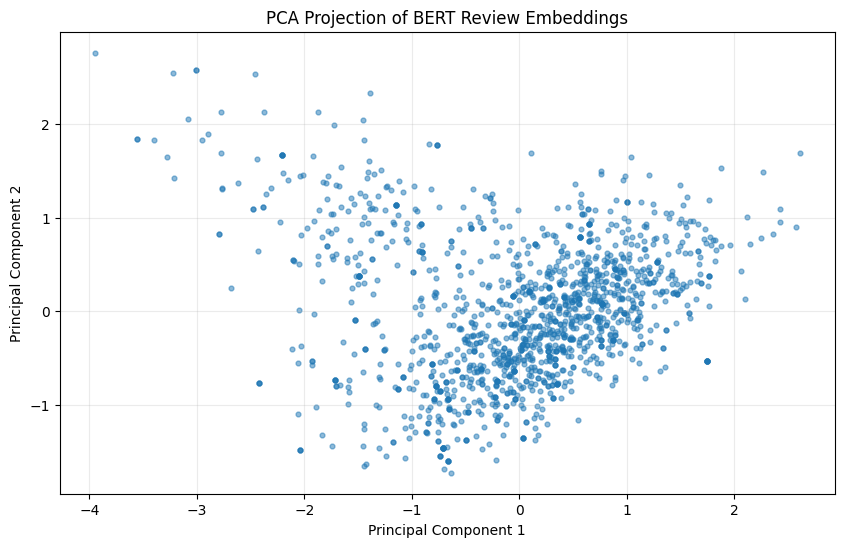

In [4]:
# PCA projection of BERT review embeddings (2D) and scatter plot
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Ensure a numeric matrix exists
if not isinstance(bert_review_embeddings, np.ndarray):
    bert_embedding_matrix = np.array(bert_review_embeddings)
else:
    bert_embedding_matrix = bert_review_embeddings

bert_pca = PCA(n_components=2, random_state=42)
bert_embedding_2d = bert_pca.fit_transform(bert_embedding_matrix)

print('BERT PCA explained variance ratio:', bert_pca.explained_variance_ratio_)
print('BERT total explained variance (2 components):', bert_pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 6))
plt.scatter(bert_embedding_2d[:, 0], bert_embedding_2d[:, 1], s=12, alpha=0.5)
plt.title('PCA Projection of BERT Review Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.25)
plt.show()

Now we will cluster using k means using the same evaluation methods as word2vec.

BERT K-means clustering with k=3 (excluding Other)
Rows used (non-Other only): 1427
Silhouette score: 0.0857


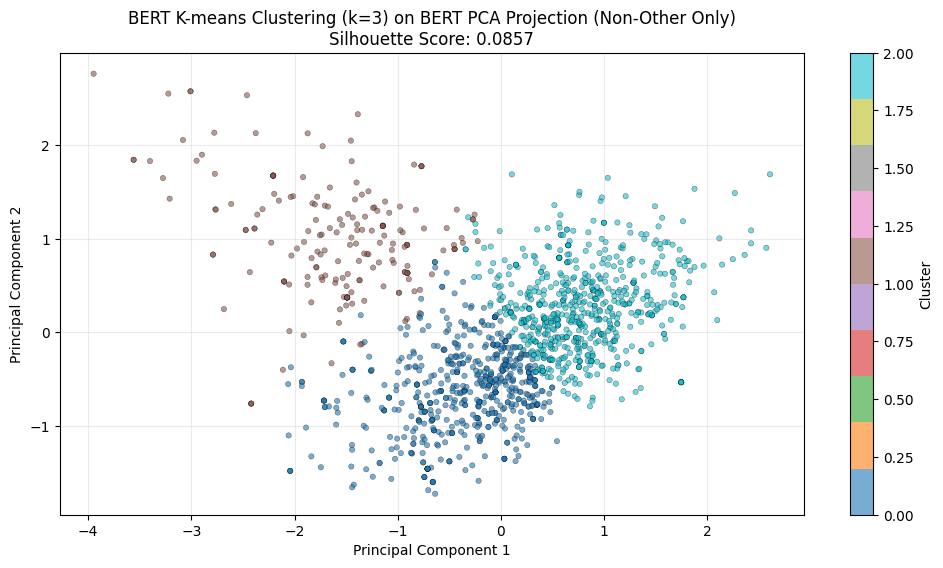


Cluster distribution:
Cluster 0: 583 reviews
Cluster 1: 188 reviews
Cluster 2: 656 reviews

--- Purity Evaluation (BERT K-means) ---
Ground truth categories used: ['Computers&Accessories', 'Electronics', 'Home&Kitchen']
Purity score: 0.4359

--- Cluster vs Ground Truth Distribution ---

Cluster 0 (total reviews: 583):
  Computers&Accessories: 186 (31.9%)
  Electronics: 280 (48.0%)
  Home&Kitchen: 117 (20.1%)

Cluster 1 (total reviews: 188):
  Computers&Accessories: 75 (39.9%)
  Electronics: 49 (26.1%)
  Home&Kitchen: 64 (34.0%)

Cluster 2 (total reviews: 656):
  Computers&Accessories: 192 (29.3%)
  Electronics: 197 (30.0%)
  Home&Kitchen: 267 (40.7%)


In [11]:
# K-means clustering on BERT embeddings (k=3) with silhouette and purity evaluation (excluding category Other)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Ensure BERT embeddings and 2D projection exist (self-contained cell)
if 'bert_embedding_matrix' not in globals():
    if not isinstance(bert_review_embeddings, np.ndarray):
        bert_embedding_matrix = np.array(bert_review_embeddings)
    else:
        bert_embedding_matrix = bert_review_embeddings

if 'bert_embedding_2d' not in globals():
    bert_pca = PCA(n_components=2, random_state=42)
    bert_embedding_2d = bert_pca.fit_transform(bert_embedding_matrix)

# Build ground truth categories first
category_counts = {}
for categories in df['category'].dropna():
    for cat in str(categories).split('|'):
        cat = cat.strip()
        if cat:
            category_counts[cat] = category_counts.get(cat, 0) + 1

top_3_categories = {
    cat for cat, _ in sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:3]
}

def assign_ground_truth_category(category_value):
    candidates = []
    for cat in str(category_value).split('|'):
        cat = cat.strip()
        if cat and cat in top_3_categories:
            candidates.append(cat)
    if not candidates:
        return 'Other'
    return max(candidates, key=lambda cat: (category_counts.get(cat, 0), cat))

ground_truth_categories = df['category'].apply(assign_ground_truth_category).values

# Exclude rows that are in category Other for clustering/plotting/evaluation
non_other_mask = ground_truth_categories != 'Other'
bert_embedding_matrix_no_other = bert_embedding_matrix[non_other_mask]
bert_embedding_2d_no_other = bert_embedding_2d[non_other_mask]
ground_truth_no_other = ground_truth_categories[non_other_mask]

# Use k=3 to mirror the updated Word2Vec setup
k = 3
bert_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
bert_best_labels = bert_kmeans.fit_predict(bert_embedding_matrix_no_other)
bert_best_silhouette = silhouette_score(bert_embedding_matrix_no_other, bert_best_labels)

print(f'BERT K-means clustering with k={k} (excluding Other)')
print(f'Rows used (non-Other only): {bert_embedding_matrix_no_other.shape[0]}')
print(f'Silhouette score: {bert_best_silhouette:.4f}')

# Visualize clusters on BERT PCA projection (non-Other points only)
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    bert_embedding_2d_no_other[:, 0],
    bert_embedding_2d_no_other[:, 1],
    c=bert_best_labels,
    cmap='tab10',
    s=15,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.3,
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'BERT K-means Clustering (k={k}) on BERT PCA Projection (Non-Other Only)\nSilhouette Score: {bert_best_silhouette:.4f}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.25)
plt.show()

print('\nCluster distribution:')
unique, counts = np.unique(bert_best_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f'Cluster {cluster_id}: {count} reviews')

# Create mapping on non-Other labels only
unique_categories = sorted(set(ground_truth_no_other))
category_to_label = {cat: i for i, cat in enumerate(unique_categories)}
ground_truth_labels = np.array([category_to_label[cat] for cat in ground_truth_no_other])

def calculate_purity(true_labels, predicted_labels):
    n = len(true_labels)
    purity_sum = 0
    for cluster_id in np.unique(predicted_labels):
        mask = predicted_labels == cluster_id
        true_labels_in_cluster = true_labels[mask]
        if len(true_labels_in_cluster) > 0:
            purity_sum += np.bincount(true_labels_in_cluster).max()
    return purity_sum / n

bert_purity = calculate_purity(ground_truth_labels, bert_best_labels)

print('\n--- Purity Evaluation (BERT K-means) ---')
print(f'Ground truth categories used: {unique_categories}')
print(f'Purity score: {bert_purity:.4f}')

print('\n--- Cluster vs Ground Truth Distribution ---')
for cluster_id in range(k):
    mask = bert_best_labels == cluster_id
    cluster_ground_truth = ground_truth_labels[mask]
    total_in_cluster = np.sum(mask)
    print(f'\nCluster {cluster_id} (total reviews: {total_in_cluster}):')
    for category_id, category_name in enumerate(unique_categories):
        count = np.sum(cluster_ground_truth == category_id)
        pct = 100 * count / total_in_cluster if total_in_cluster > 0 else 0
        print(f'  {category_name}: {count} ({pct:.1f}%)')

The silhouette score is slightly worse for this vector. If we tested multiple k values, then BERT may be higher. However, for k = 3, BERT does not have tight clusters. While the purity score is slightly lower, the clusters have a majority for each category. BERT is able to differentiate electronics and home&kitchen unlike word2vec.

## Results

We set off to find interesting clusters from review embeddings.

I got embeddings from the reviews using word2vec and BERT. I clustered PCA projections using k-means and evaluated using silhouette and purity scores using categories as labels. 

I got relatively low silhouette scores for both word2vec and BERT. This is not surprising because the projections did not have the structure of clusters. The embeddings centered around one point and got uniformly less dense the further away from the center the points were. This is expected behavior of review embeddings.

The purity scores were 0.46 and 0.44 respectively. These show a slight correlation of embeddings with category. Word2vec seemed to treat electronics and home&kitchen as the same which is similar to the behavior of part 1. BERT generated clear clusters for each category. Although the clusters had many embeddings from other categories. It is still a very interesting that the clusters that emerged correlated to specific categories.

## Resources.

On my honor, I declare the following resources:
1. Collaborators:
None

2. Web Sources:
None

3. AI Tools:
Github Copilot Agent (GPT-5.1): I prompted for code one cell at a time and wrote analysis in between. I had to rewrite cells a few time.

# Conclusion

The questions that I developed for this dataset of amazon products and reviews were "Are ratings biased by the category or discounted amount?" and "What clusters emerge from review text embeddings?"

I determined through a thorough analysis of the dataset that the ratings were biased by category for computer&accessories, but I did not find evidence that ratings were biased for electronics and home&kitchen. I also could not conclude that ratings were biased by the discounted price.

Solely looking at the clusters from a structural perspective, the clusters were not particularly interesting. However, when using the category as ground truth, we found some very interesting findings. Word2vec can not find a difference between electronics and home&kitchen, which the same conclusion we came to when researching the first question. On the other hand,BERT created clusters that correspond to a single category each. 

## Resources.

On my honor, I declare the following resources:
1. Collaborators:
None

2. Web Sources:
None

3. AI Tools:
None